In [ ]:
# CodeAlpha - Task 1: Credit Scoring Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
!pip install -q kaggle

In [13]:
!pip install -q ucimlrepo

In [14]:
from ucimlrepo import fetch_ucirepo

german_credit = fetch_ucirepo(id=144)

X = german_credit.data.features
y = german_credit.data.targets

print("✅ Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

✅ Dataset loaded successfully!
Features shape: (1000, 20)
Target shape: (1000, 1)


In [15]:
print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("\nData types:")
print(X.dtypes)

print("\nDataset shape:")
print(X.shape)

Features:


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201



Target:


,class
0,1
1,2
2,1
3,1
4,2



Data types:
Attribute1     object
Attribute2      int64
Attribute3     object
Attribute4     object
Attribute5      int64
Attribute6     object
Attribute7     object
Attribute8      int64
Attribute9     object
Attribute10    object
Attribute11     int64
Attribute12    object
Attribute13     int64
Attribute14    object
Attribute15    object
Attribute16     int64
Attribute17    object
Attribute18     int64
Attribute19    object
Attribute20    object
dtype: object

Dataset shape:
(1000, 20)


In [16]:
print("Missing values:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

print("\nDuplicate rows:", X.duplicated().sum())

print("\nTarget distribution:")
print(y["class"].value_counts())

Missing values:
Attribute1     0
Attribute2     0
Attribute3     0
Attribute4     0
Attribute5     0
Attribute6     0
Attribute7     0
Attribute8     0
Attribute9     0
Attribute10    0
Attribute11    0
Attribute12    0
Attribute13    0
Attribute14    0
Attribute15    0
Attribute16    0
Attribute17    0
Attribute18    0
Attribute19    0
Attribute20    0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Target distribution:
class
1    700
2    300
Name: count, dtype: int64


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_processed = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Processed shape:", X_processed.shape)

Categorical columns: 13
Numerical columns: 7
Original shape: (1000, 20)
Processed shape: (1000, 61)


In [18]:
from sklearn.model_selection import train_test_split

# Convert target: 1 = Good -> 0, 2 = Bad -> 1
y_encoded = y["class"].map({1: 0, 2: 1})

print("Target values:")
print(y_encoded.value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

Target values:
class
0    700
1    300
Name: count, dtype: int64

Training data: (800, 61)
Testing data: (200, 61)


In [19]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("✅ Logistic Regression trained successfully!")

✅ Logistic Regression trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Prediction probabilities for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("✅ Predictions completed!")
print("First 10 predictions:", y_pred_logistic[:10])

✅ Predictions completed!
First 10 predictions: [0 0 1 1 0 0 0 0 1 0]


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.78
Precision: 0.66
Recall   : 0.55
F1-Score : 0.6
ROC-AUC  : 0.8077


In [22]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train, y_train)

print("✅ Decision Tree trained successfully!")

✅ Decision Tree trained successfully!


In [23]:
# Predictions
y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

# Evaluation
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1-Score :", round(f1_tree, 4))
print("ROC-AUC  :", round(roc_auc_tree, 4))

Decision Tree Results
---------------------
Accuracy : 0.645
Precision: 0.4179
Recall   : 0.4667
F1-Score : 0.4409
ROC-AUC  : 0.676


In [24]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train, y_train)

print("✅ Random Forest trained successfully!")

✅ Random Forest trained successfully!


In [25]:
# Random Forest predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Results
---------------------
Accuracy : 0.765
Precision: 0.7097
Recall   : 0.3667
F1-Score : 0.4835
ROC-AUC  : 0.8006


Logistic Regression


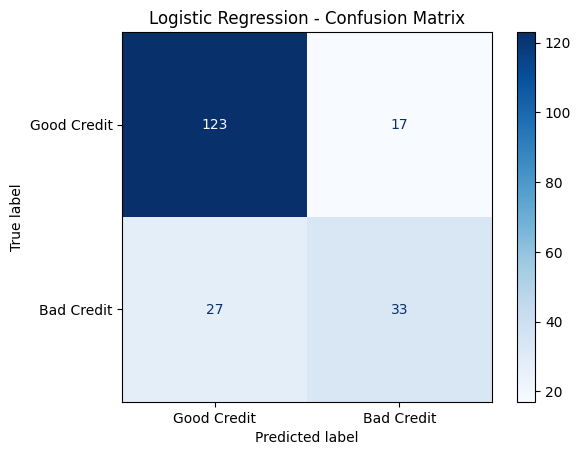

Random Forest


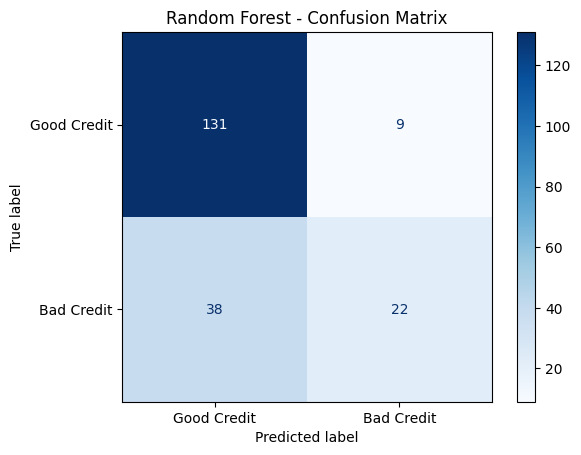

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression
print("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Good Credit", "Bad Credit"],
    cmap="Blues"
)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Random Forest
print("Random Forest")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Good Credit", "Bad Credit"],
    cmap="Blues"
)
plt.title("Random Forest - Confusion Matrix")
plt.show()

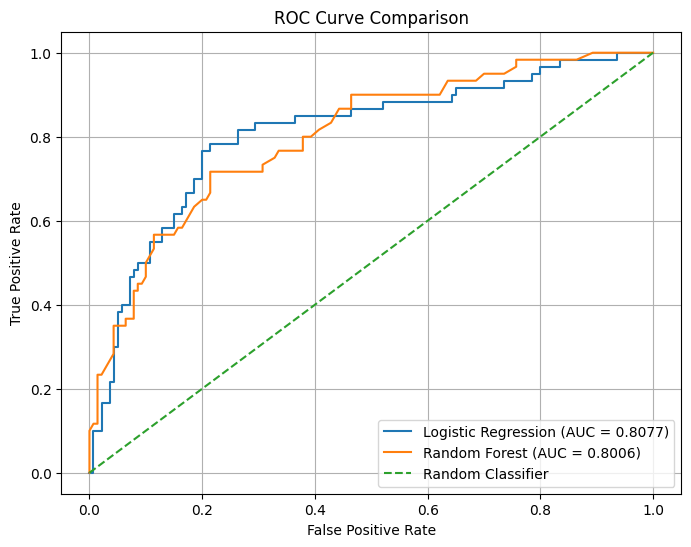

In [28]:
from sklearn.metrics import roc_curve, auc

# ROC curves
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_logistic = auc(fpr_logistic, tpr_logistic)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [29]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf
    ],
    "F1-Score": [
        f1,
        f1_tree,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.780,0.6600,0.5500,0.6000,0.8077
1,Decision Tree,0.645,0.4179,0.4667,0.4409,0.6760
2,Random Forest,0.765,0.7097,0.3667,0.4835,0.8006


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Logistic Regression pipeline
final_logistic_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=42
    ))
])

# Train final Logistic Regression
final_logistic_model.fit(X_train, y_train)

print("✅ Final Logistic Regression trained successfully!")

✅ Final Logistic Regression trained successfully!


In [31]:
# Predictions from final model
y_pred_final = final_logistic_model.predict(X_test)
y_prob_final = final_logistic_model.predict_proba(X_test)[:, 1]

# Final evaluation
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_prob_final)

print("Final Logistic Regression Results")
print("---------------------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1-Score :", round(final_f1, 4))
print("ROC-AUC  :", round(final_roc_auc, 4))

Final Logistic Regression Results
---------------------------------
Accuracy : 0.775
Precision: 0.6364
Recall   : 0.5833
F1-Score : 0.6087
ROC-AUC  : 0.7996


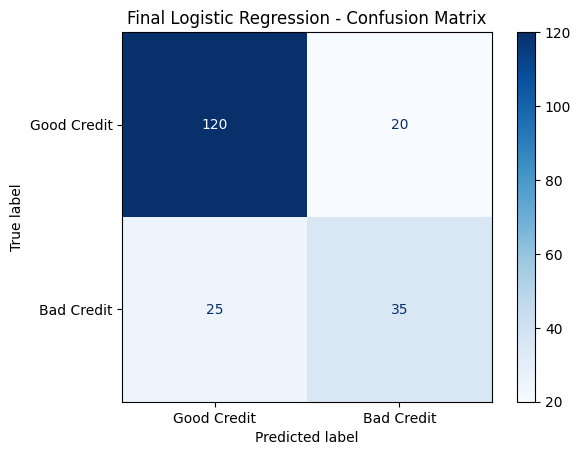

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["Good Credit", "Bad Credit"],
    cmap="Blues"
)

plt.title("Final Logistic Regression - Confusion Matrix")
plt.show()

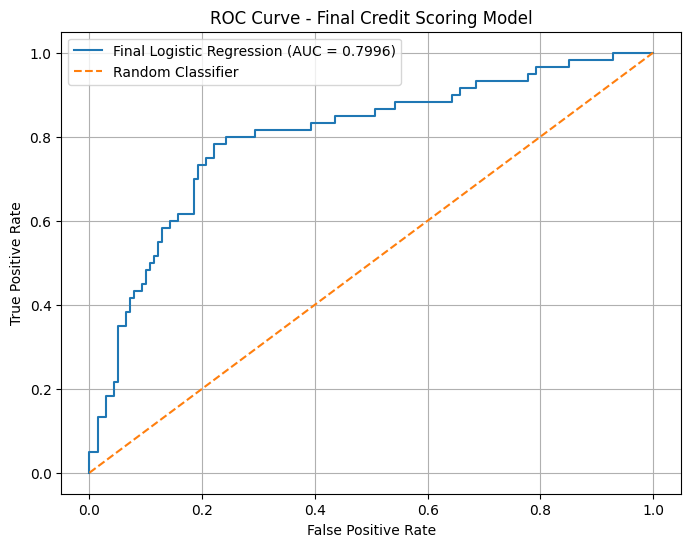

Final ROC-AUC: 0.7996


In [33]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr_final, tpr_final, thresholds = roc_curve(
    y_test,
    y_prob_final
)

final_auc = auc(fpr_final, tpr_final)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_final,
    tpr_final,
    label=f"Final Logistic Regression (AUC = {final_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Credit Scoring Model")
plt.legend()
plt.grid()
plt.show()

print("Final ROC-AUC:", round(final_auc, 4))

In [34]:
# Get feature names after One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = final_logistic_model.named_steps["model"].coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(feature_importance.head(15))

Top 15 Important Features:


,Feature,Coefficient,Absolute_Importance
3,cat__Attribute1_A14,-0.430226,0.430226
56,remainder__Attribute8,0.396451,0.396451
55,remainder__Attribute5,0.344646,0.344646
39,cat__Attribute12_A124,0.344264,0.344264
54,remainder__Attribute2,0.331623,0.331623
0,cat__Attribute1_A11,0.328268,0.328268
8,cat__Attribute3_A34,-0.283921,0.283921
45,cat__Attribute15_A153,-0.276650,0.276650
10,cat__Attribute4_A41,-0.254644,0.254644
19,cat__Attribute6_A61,0.248751,0.248751


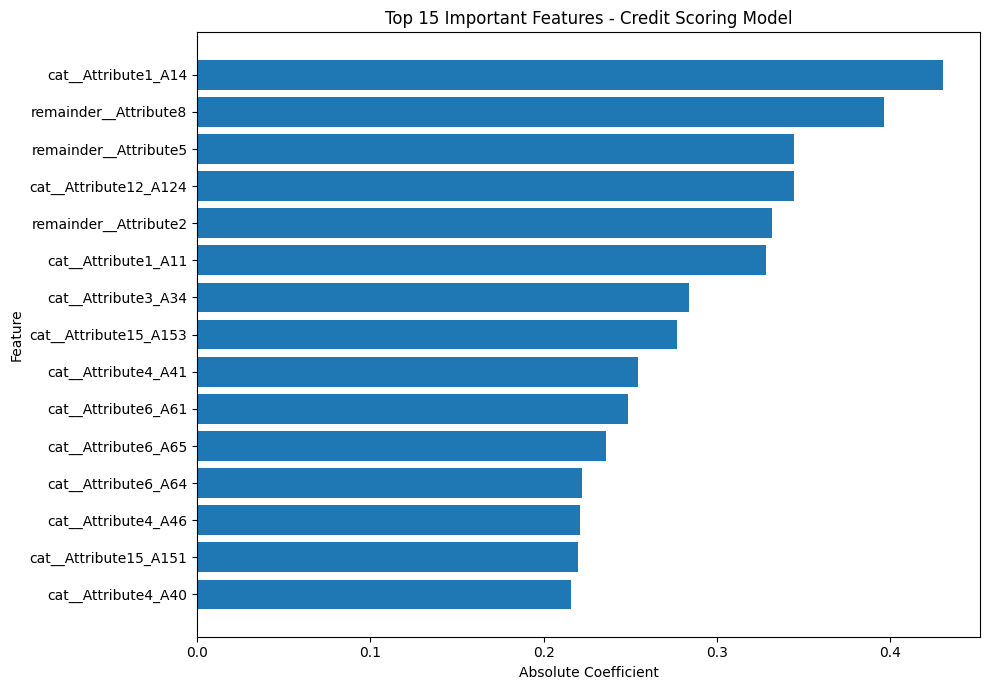

In [35]:
top_features = feature_importance.head(15).sort_values(
    by="Absolute_Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Importance"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Important Features - Credit Scoring Model")

plt.tight_layout()
plt.show()

In [36]:
import joblib

# Save final Logistic Regression model
joblib.dump(
    final_logistic_model,
    "credit_scoring_model.pkl"
)

# Save preprocessing object
joblib.dump(
    preprocessor,
    "credit_preprocessor.pkl"
)

print("✅ Final model saved!")
print("✅ Preprocessor saved!")

✅ Final model saved!
✅ Preprocessor saved!


In [37]:
import os

print("Saved files:")

for file in ["credit_scoring_model.pkl", "credit_preprocessor.pkl"]:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024 * 1024)
        print(f"✅ {file} — {size:.2f} MB")
    else:
        print(f"❌ {file} not found")

Saved files:
✅ credit_scoring_model.pkl — 0.00 MB
✅ credit_preprocessor.pkl — 0.01 MB


In [38]:
from google.colab import files

files.download("credit_scoring_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
files.download("credit_preprocessor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
test_predictions = final_logistic_model.predict(X_test)

print("✅ Final model prediction test successful!")
print("Number of predictions:", len(test_predictions))
print("First 10 predictions:", test_predictions[:10])

✅ Final model prediction test successful!
Number of predictions: 200
First 10 predictions: [0 0 1 1 0 0 0 0 1 0]
